In [40]:
import numpy as np
import ants
import matplotlib.pyplot as plt
import os
from antspynet.utilities import brain_extraction

2025-06-27 15:13:49.724483: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-27 15:13:49.806089: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-27 15:13:49.830256: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-27 15:13:50.005072: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def porcentagem_limiar(values, thresh): #vê qual o porcentagem de valores acima de um threshold
    if len(values.shape) > 1:
        values = values.flatten()

    thresh_count = 0
    
    for value in values:
        if value > thresh:
            thresh_count += 1

    print(f"TOTAL VOXELS: {len(values)} \nMAIOR QUE {thresh}: {thresh_count} \nrazão: {(thresh_count/len(values))*100:.2f}%")

def metricas_imagem(data): #print metricas de uma imagem (max, min, media)
    if len(data.shape) > 1:
        values = data.flatten()

    print(f"MEDIA: {np.mean(values)}")
    print(f"MIN: {np.min(values)}")
    print(f"MAX: {np.max(values)}")

    plt.hist(values)
    plt.show()

def winsorize_image(image_data, lower_percentile=1, upper_percentile=98): #reduz valores extremos
    lower_bound = np.percentile(image_data, lower_percentile)
    upper_bound = np.percentile(image_data, upper_percentile)
    winsorized_data = np.clip(image_data, lower_bound, upper_bound)
    return winsorized_data

def normalize_image_min(image_data): #normalizar 
    min_val = np.min(image_data)
    max_val = np.max(image_data)
    normalized_data = (image_data - min_val) / (max_val - min_val)
    return normalized_data

In [3]:
dir = 'test_raw'

path = "test_raw/emci/I279107.nii.gz"

img = ants.image_read(path)
img_data = img.numpy()

template_path = "mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/mni_icbm152_t1_tal_nlin_asym_09c.nii"
template = ants.image_read(template_path)

MEDIA: 267.6585388183594
MIN: 0.0
MAX: 5108.42333984375


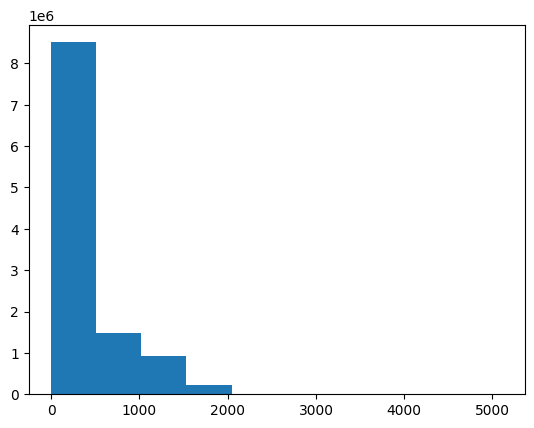

TOTAL VOXELS: 11141120 
MAIOR QUE 2300: 3533 
razão: 0.03%


In [4]:
metricas_imagem(img_data)
porcentagem_limiar(img_data, 2300)

MEDIA: 0.052395522594451904
MIN: 0.0
MAX: 1.0


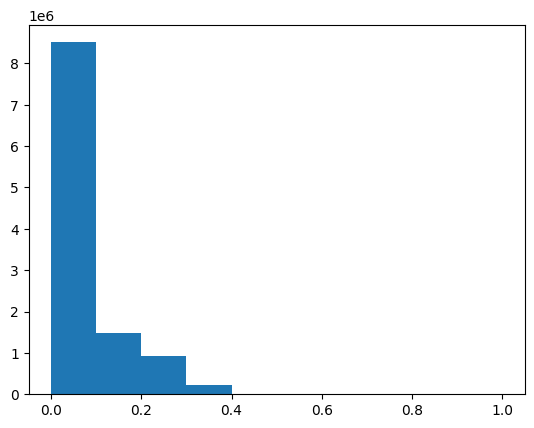

In [5]:
norm_sem_wins_data = normalize_image_min(img_data)
metricas_imagem(norm_sem_wins_data)

MEDIA: 267.3624572753906
MIN: 0.0
MAX: 2040.1181640625


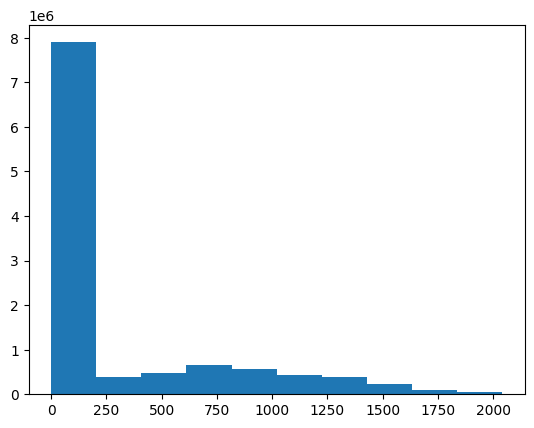

In [6]:
wins_data = winsorize_image(img_data, 1, 99.9)
metricas_imagem(wins_data)

MEDIA: 0.13105255365371704
MIN: 0.0
MAX: 1.0


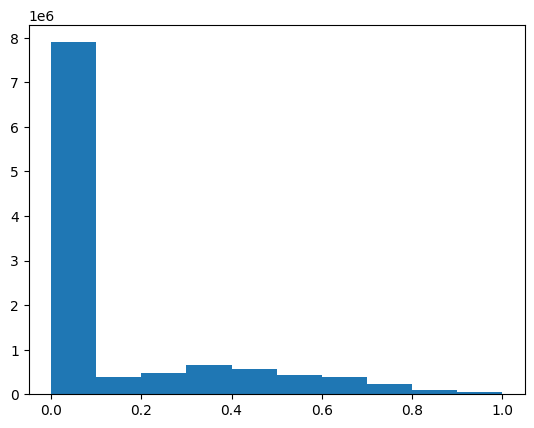

In [7]:
norm_data = normalize_image_min(wins_data)
metricas_imagem(norm_data)

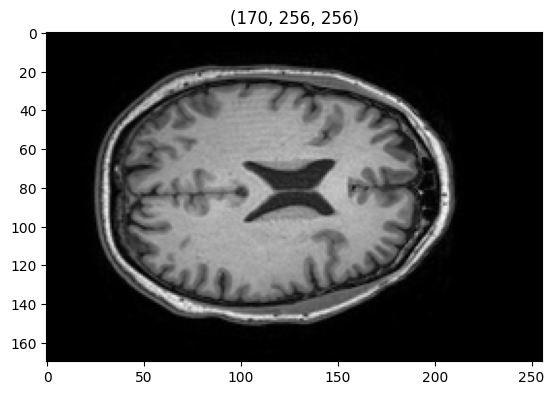

In [26]:
plt.imshow(img_data[:, :, 133], cmap="gray")
plt.title(img_data.shape)
plt.show()

In [8]:
registration = ants.registration(fixed=template, moving=img, type_of_transform='Translation')
trans_image = registration['warpedmovout']

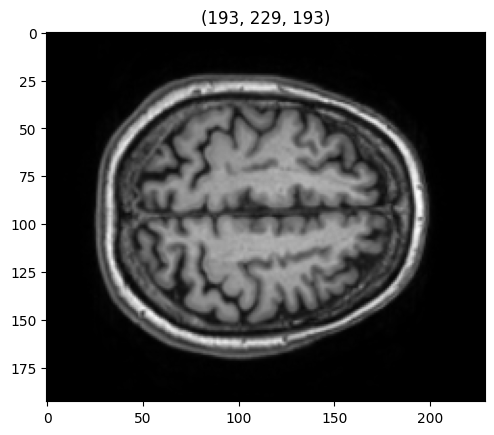

In [24]:
plt.imshow(trans_image.numpy()[:, :, 133], cmap="gray")
plt.title(trans_image.shape)
plt.show()

In [10]:
registration = ants.registration(fixed=template, moving=trans_image, type_of_transform='Rigid')
rigid_image = registration['warpedmovout']

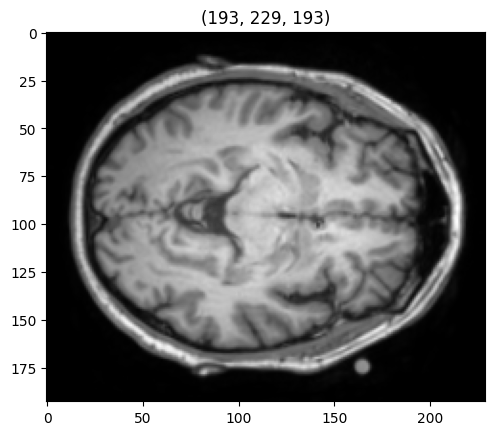

In [21]:
plt.imshow(rigid_image.numpy()[:, :, 80], cmap="gray")
plt.title(rigid_image.shape)
plt.show()

In [12]:
registration = ants.registration(fixed=template, moving=rigid_image, type_of_transform='Affine')
affine_image = registration['warpedmovout']

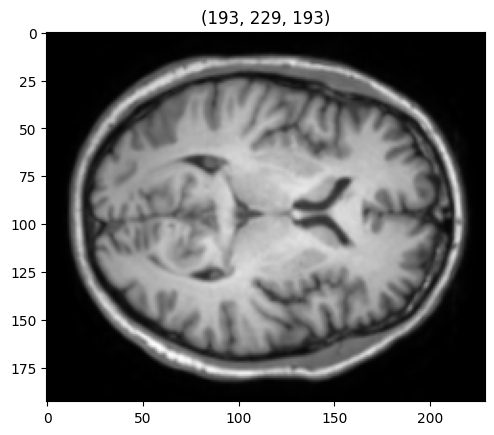

In [22]:
plt.imshow(affine_image.numpy()[:, :, 80], cmap="gray")
plt.title(affine_image.shape)
plt.show()

In [ ]:
registration = ants.registration(fixed=template, moving=affine_image, type_of_transform='SyN')
syn_image = registration['warpedmovout']

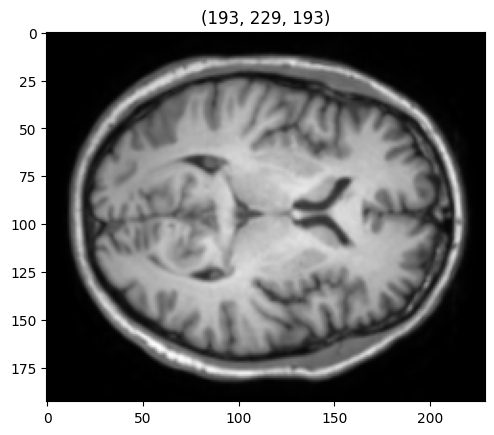

In [23]:
plt.imshow(affine_image.numpy()[:, :, 80], cmap="gray")
plt.title(syn_image.shape)
plt.show()

MEDIA: 414.0349426269531
MIN: 0.0
MAX: 3144.021728515625


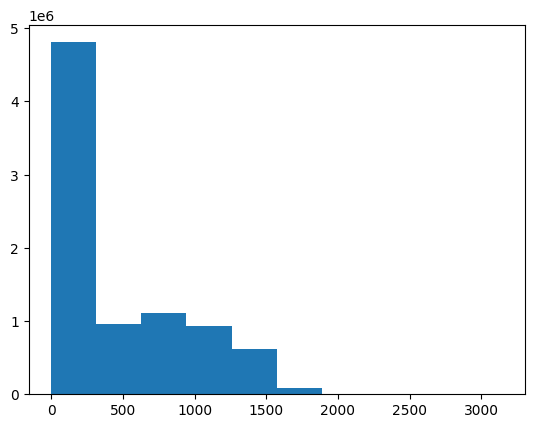

In [16]:
affine_data = affine_image.numpy()
metricas_imagem(affine_data)

MEDIA: 413.9187927246094
MIN: 0.0
MAX: 1854.6175537109375


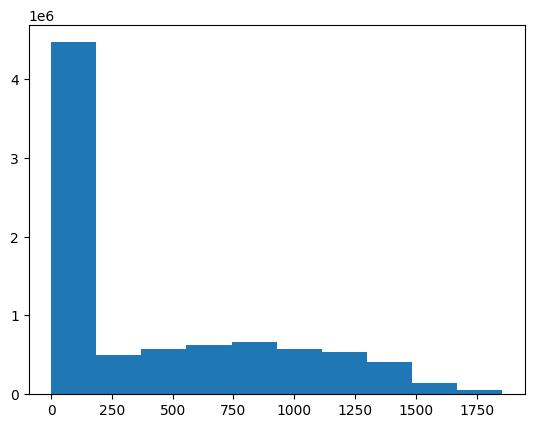

In [18]:
affine_norm = winsorize_image(affine_data, 1, 99.9)
metricas_imagem(affine_norm)

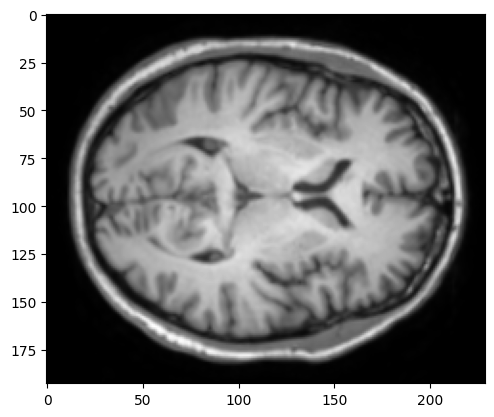

In [20]:
plt.imshow(affine_norm[:, :, 80], cmap='gray')
plt.show()

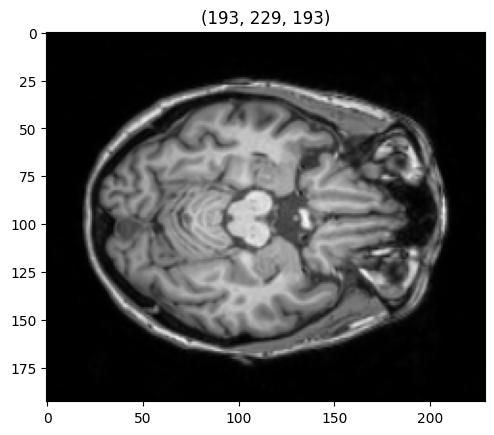

MEDIA: 0.1495811641216278
MIN: 0.0
MAX: 1.0


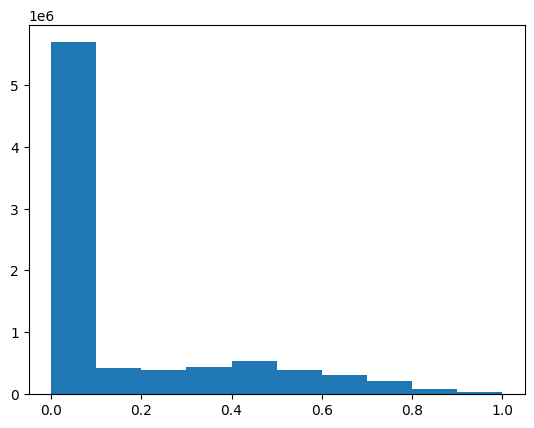

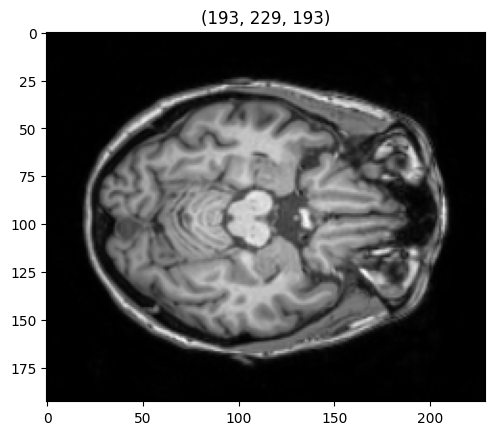

MEDIA: 0.14977841079235077
MIN: 0.0
MAX: 1.0


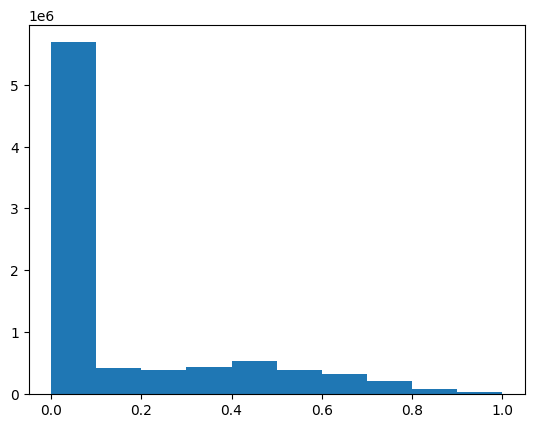

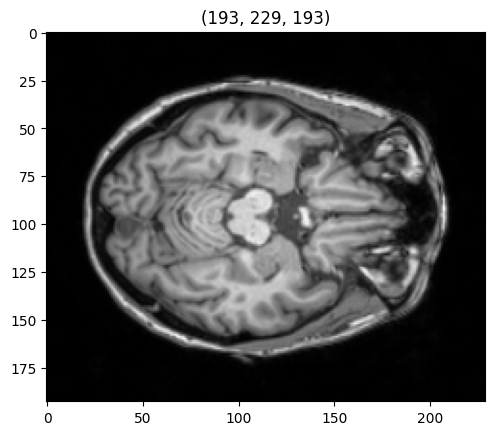

MEDIA: 0.14969784021377563
MIN: 0.0
MAX: 1.0


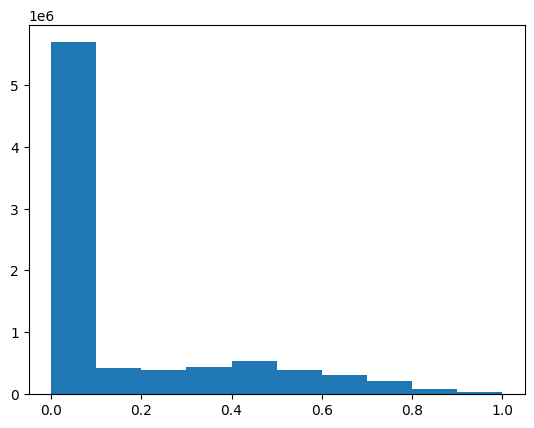

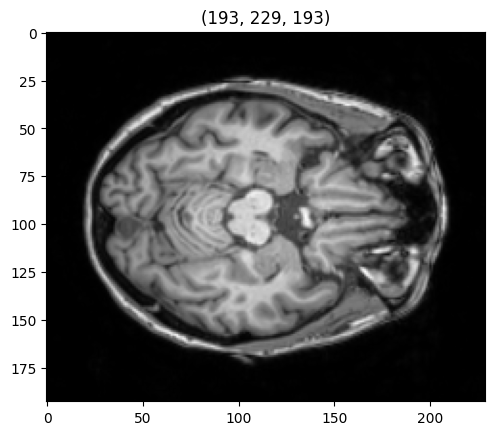

MEDIA: 0.1498854011297226
MIN: 0.0
MAX: 1.0


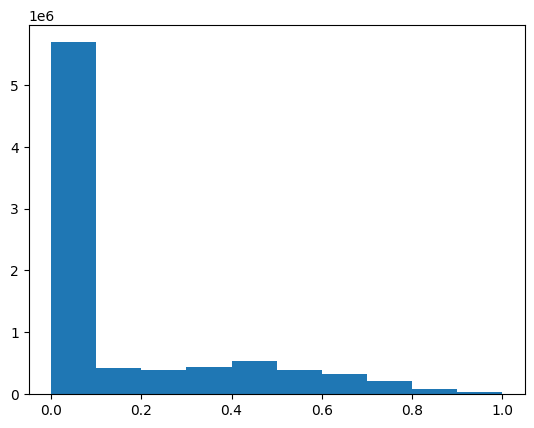

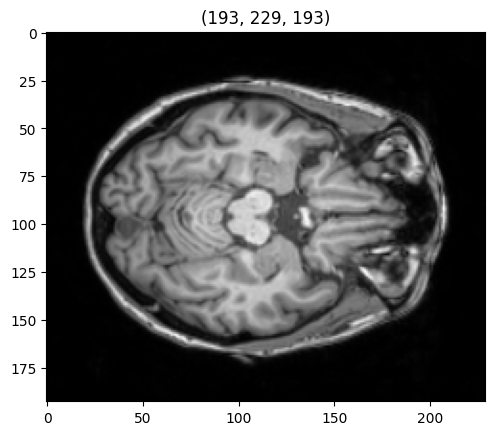

MEDIA: 0.1497957706451416
MIN: 0.0
MAX: 1.0


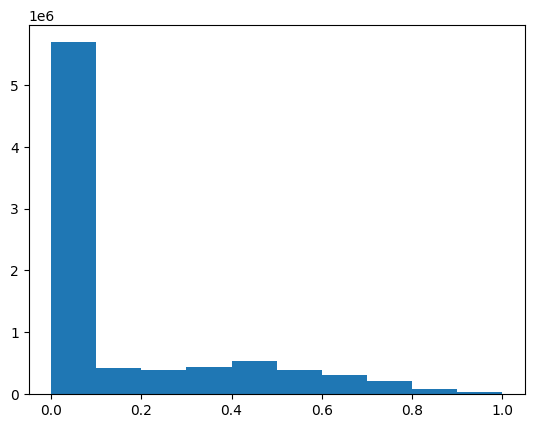

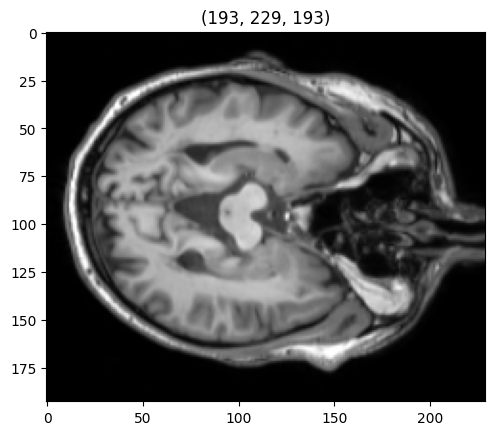

MEDIA: 0.17662161588668823
MIN: 0.0
MAX: 1.0


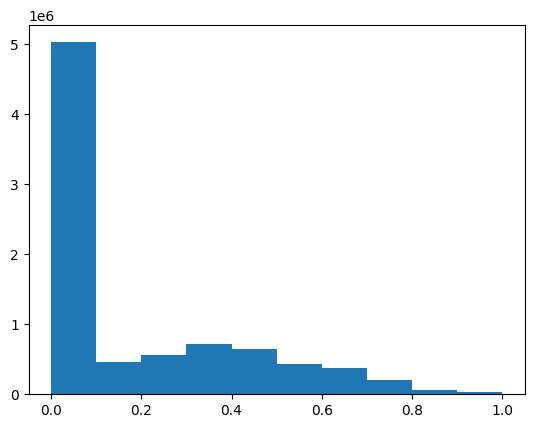

KeyboardInterrupt: 

In [ ]:
dir = 'test_raw'

folders = os.listdir(dir)

for subset in folders:
    count = 0
    subset_path = f"{dir}/{subset}"

    names = os.listdir(subset_path)
    for name in names:
        while count < 1:
            name_path = f"{subset_path}/{name}"
            pre_data = ants.image_read(name_path)

            registration = ants.registration(fixed=template, moving=pre_data, type_of_transform='Rigid')
            rigid_data = registration['warpedmovout']

            # Cria template pra máscara
            prob_mask = brain_extraction(affine_data, modality='t1') # MODALIDADE: 'flair' ou 't1'

            # Cria a máscara
            mask = ants.get_mask(prob_mask, low_thresh=0.5)

            # Máscara do cérebro e extração
            brain_masked = ants.mask_image(affine_data, mask)

            wins_data = winsorize_image(affine_data.numpy(), 1, 99.9)

            norm_wins_data = normalize_image_min(wins_data)

            plt.imshow(norm_wins_data[:, :, 80], cmap='gray')
            plt.title(norm_wins_data.shape)
            plt.show()

            metricas_imagem(norm_wins_data)
            count += 1